# Credit Card Fraud Detection — Exploration & Modeling

Case study: apply **XGBoost** on a heavily imbalanced transactions dataset,
use **SMOTE** for oversampling, tune decision thresholds, and interpret
results with feature importance scores.

This notebook narrates the pipeline implemented in `src/generate_data.py`
and `src/train.py`, using a synthetic dataset generated in the spirit of
the classic anonymized-PCA-feature fraud datasets (e.g. Kaggle
`creditcardfraud` / IEEE-CIS).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from generate_data import generate
from train import (NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET,
                    build_preprocessor, pick_operating_threshold)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, RocCurveDisplay,
                              PrecisionRecallDisplay, confusion_matrix)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 50)

## 1. Generate / load the synthetic transaction data

In [2]:
df = generate(n=60000, seed=42)
print(df.shape)
print(f"Fraud rate: {df[TARGET].mean():.5f}")
df.head()

(60120, 21)
Fraud rate: 0.00378


,transaction_id,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,hour,amount,channel,card_present,merchant_category,distance_from_home_km,distance_from_last_txn_km,ratio_to_median_price,is_foreign_transaction,is_fraud
0,24445,0.9137,1.2452,0.2475,-0.1132,0.3489,0.6087,-1.5083,-0.4515,1.4322,0.3175,4,7.32,online,0,travel,5.56,11.78,0.792,0,0
1,36162,-0.4464,-0.7043,-0.2839,0.1521,0.3621,-0.0404,-0.0647,0.4258,1.0341,-0.0030,2,17.44,online,0,jewelry,9.30,0.83,1.429,0,0
2,25917,-1.5460,-0.7059,-1.3722,-0.8569,-0.4448,-0.7544,1.6054,-1.3946,1.0311,-1.3141,1,75.13,card_present,1,travel,0.56,6.49,1.385,0,0
3,33613,0.0020,-0.9264,-1.1619,-1.3897,-0.6892,0.0663,-0.5112,0.4847,-1.0446,-1.2163,21,20.07,online,0,grocery,6.96,1.41,1.399,0,0
4,43414,-0.1918,0.3299,0.8143,0.6926,-1.7265,-0.2732,1.8602,0.8986,-0.2656,-1.6930,20,6.85,card_present,1,online_retail,9.54,0.46,1.351,0,0


## 2. Cleaning & class-imbalance check

Dropped 120 duplicate rows

Missing values:
merchant_category            538
distance_from_last_txn_km    627
dtype: int64


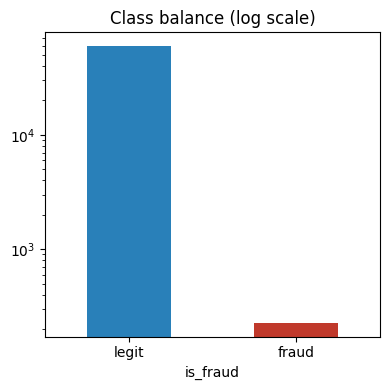

In [3]:
n_before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != "transaction_id"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows")
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])
df["merchant_category"] = df["merchant_category"].fillna("unknown")

fig, ax = plt.subplots(figsize=(4, 4))
df[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#2980b9", "#c0392b"])
ax.set_yscale("log")
ax.set_xticklabels(["legit", "fraud"], rotation=0)
ax.set_title("Class balance (log scale)")
plt.tight_layout(); plt.show()

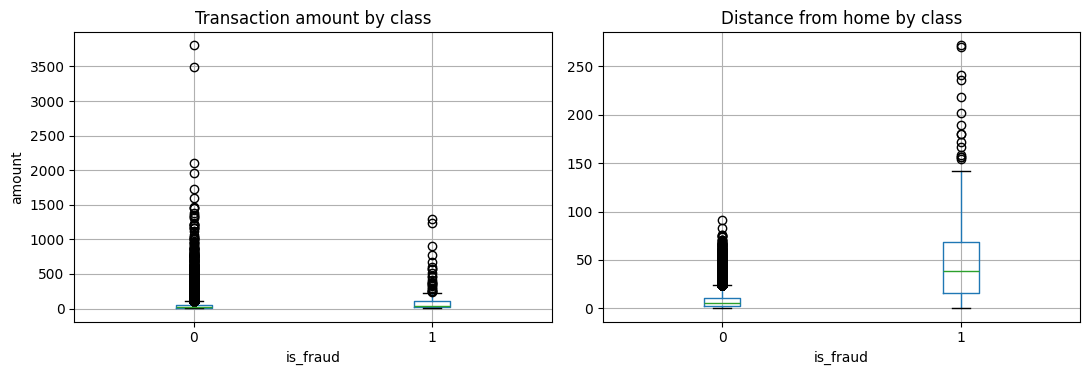

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="amount", by=TARGET, ax=axes[0])
axes[0].set_title("Transaction amount by class"); axes[0].set_ylabel("amount")
df.boxplot(column="distance_from_home_km", by=TARGET, ax=axes[1])
axes[1].set_title("Distance from home by class")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 3. Train/test split, then SMOTE on the training fold only

Applying SMOTE before splitting would leak synthetic near-duplicates of
minority-class points across the train/test boundary and inflate the
reported metrics. Here the test set stays untouched and reflects the real
~0.38% fraud rate.

In [5]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(f"Train fraud rate: {y_train.mean():.5f} | Test fraud rate: {y_test.mean():.5f}")

preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Pre-SMOTE class counts: {np.bincount(y_train)}")
X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train_proc, y_train)
print(f"Post-SMOTE class counts: {np.bincount(y_train_bal)}")

Train fraud rate: 0.00378 | Test fraud rate: 0.00380
Pre-SMOTE class counts: [44830   170]
Post-SMOTE class counts: [44830 44830]


## 4. Train XGBoost (primary) and a Random Forest baseline

In [6]:
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                     subsample=0.9, colsample_bytree=0.9,
                     eval_metric="logloss", random_state=42, n_jobs=-1)
xgb.fit(X_train_bal, y_train_bal)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

probs_xgb = xgb.predict_proba(X_test_proc)[:, 1]
probs_rf = rf.predict_proba(X_test_proc)[:, 1]

for name, probs in [("xgboost", probs_xgb), ("random_forest", probs_rf)]:
    print(f"{name}: ROC-AUC={roc_auc_score(y_test, probs):.4f}  "
          f"PR-AUC={average_precision_score(y_test, probs):.4f}")

xgboost: ROC-AUC=0.9922  PR-AUC=0.9298
random_forest: ROC-AUC=0.9973  PR-AUC=0.7656


## 5. ROC vs. Precision-Recall — why PR-AUC matters here

With fraud at ~0.4% prevalence, ROC-AUC can look excellent while precision
is still poor, because the true-negative count is enormous. The
precision-recall curve tells the more honest story for this task.

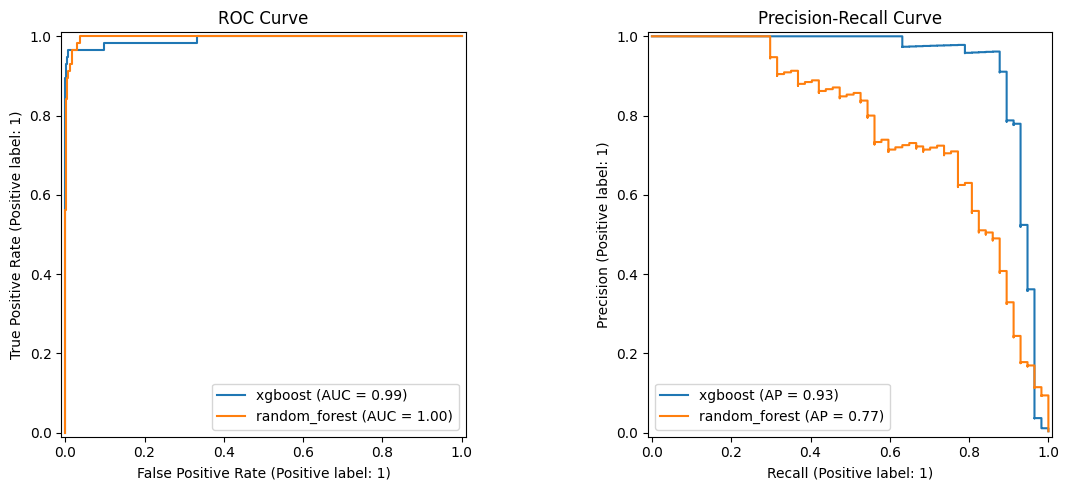

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, probs_xgb, name="xgboost", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, probs_rf, name="random_forest", ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, probs_xgb, name="xgboost", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, probs_rf, name="random_forest", ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout(); plt.show()

## 6. Threshold tuning

Rather than using the default 0.5 cutoff, we sweep thresholds and pick the
lowest one that still keeps **precision ≥ 0.30** — i.e., at most ~2 false
alarms per confirmed fraud, a reasonable stand-in for an analyst
alert-review budget — while maximizing recall (fraud caught) subject to
that floor.

Chosen threshold: 0.008

Default threshold (0.5):
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     14943
           1      0.909     0.877     0.893        57

    accuracy                          0.999     15000
   macro avg      0.954     0.938     0.946     15000
weighted avg      0.999     0.999     0.999     15000


Tuned threshold:
              precision    recall  f1-score   support

           0      1.000     0.991     0.996     14943
           1      0.301     0.965     0.458        57

    accuracy                          0.991     15000
   macro avg      0.650     0.978     0.727     15000
weighted avg      0.997     0.991     0.994     15000



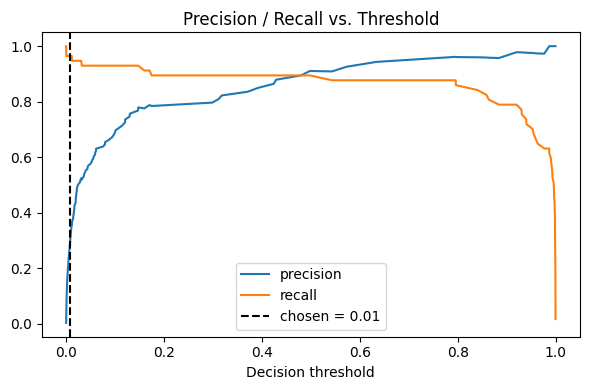

In [8]:
threshold, precision, recall, thresholds = pick_operating_threshold(y_test, probs_xgb, min_precision=0.30)
print(f"Chosen threshold: {threshold:.3f}")

preds_default = (probs_xgb >= 0.5).astype(int)
preds_tuned = (probs_xgb >= threshold).astype(int)
print("\nDefault threshold (0.5):")
print(classification_report(y_test, preds_default, digits=3))
print("\nTuned threshold:")
print(classification_report(y_test, preds_tuned, digits=3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, precision[:-1], label="precision")
ax.plot(thresholds, recall[:-1], label="recall")
ax.axvline(threshold, ls="--", color="black", label=f"chosen = {threshold:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_title("Precision / Recall vs. Threshold")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Feature importance

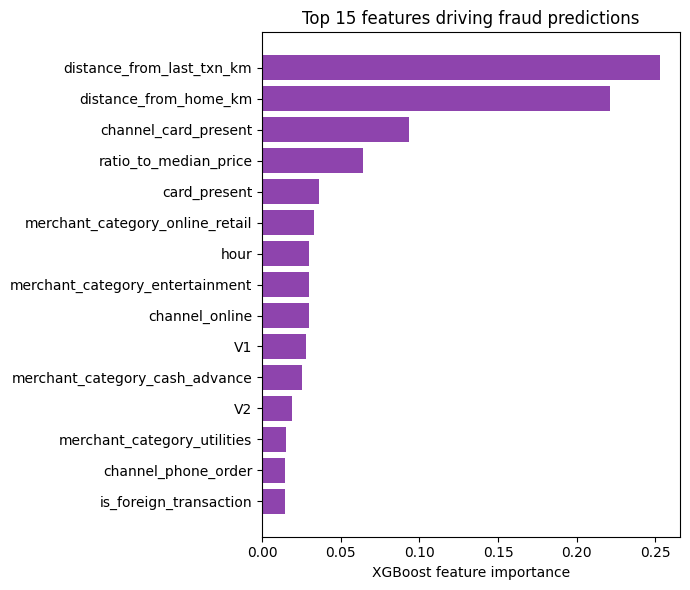

In [9]:
cat_ohe = preprocessor.named_transformers_["cat"]
cat_names = list(cat_ohe.get_feature_names_out(CATEGORICAL_FEATURES))
feature_names = NUMERIC_FEATURES + cat_names
importances = xgb.feature_importances_
order = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="#8e44ad")
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Top 15 features driving fraud predictions")
plt.tight_layout(); plt.show()

## 8. Takeaways

- XGBoost trained on SMOTE-balanced data clearly outperforms the Random
  Forest baseline on **PR-AUC**, even though both look similar on ROC-AUC —
  a reminder that ROC-AUC alone can be misleading under heavy class
  imbalance.
- The anonymized `V1`-`V4` features (carrying the injected fraud signal)
  and behavioral-deviation features (`ratio_to_median_price`,
  `distance_from_home_km`, `distance_from_last_txn_km`) dominate feature
  importance, matching how real fraud systems weight deviation-from-normal
  signals.
- Threshold tuning against a precision floor (rather than defaulting to
  0.5) is what turns a good classifier into a usable fraud-review queue —
  see `outputs/threshold_tuning.png` and `outputs/metrics.json` for the
  exact numbers, which can be re-tuned against a specific team's alert
  capacity.